# Required Packages:

- NumPy: For numerical computing
- Matplotlib: For visualizing solution to ODE and its applications
- Jupyter Lab: For running Jupyter notebooks.

All these packages are mentioned in `requirements.txt`

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from solver import ivp

# Error Function:

The error function is defined as area under the curve $f(x)=\frac{2}{\sqrt{\pi}}e^{-x^2}$ from $x=0$ to $x=x$.

$$\therefore \mathrm{erf}(x)=\int_{0}^{x}{\frac{2}{\sqrt{\pi}}e^{-t^2}dt}$$

We can also express this as an IVP:
$$
\frac{dy}{dx}=\frac{2}{\sqrt{\pi}}e^{-x^2}\qquad y(0)=0
$$
Now before solving, we need to look at one more property of $\mathrm{erf}(x)$, that is $\mathrm{erf}(-x)=-\mathrm{erf}(x)$ because,
$$\begin{align*}
&\mathrm{erf}(-x)=\int_{0}^{-x}{\frac{2}{\sqrt{\pi}}e^{-t^2}dt}\\
&\text{Let }t=-u\implies dt=-du\\
&\therefore 0\rightarrow0\qquad -x\rightarrow x\\
&\mathrm{erf}(-x)=\int_{0}^{x}{\frac{2}{\sqrt{\pi}}e^{-u^2}(-du)}=-\int_{0}^{x}{\frac{2}{\sqrt{\pi}}e^{-u^2}du}=-\mathrm{erf}(x)
\end{align*}$$
Now we will just have to run our solver for $x\geq0$ and the for $x<0$, we just  have to multiply the solver's result by $-1$.

We'll use RK4 method, because its error is in order of $\mathcal{O}(h^4)$

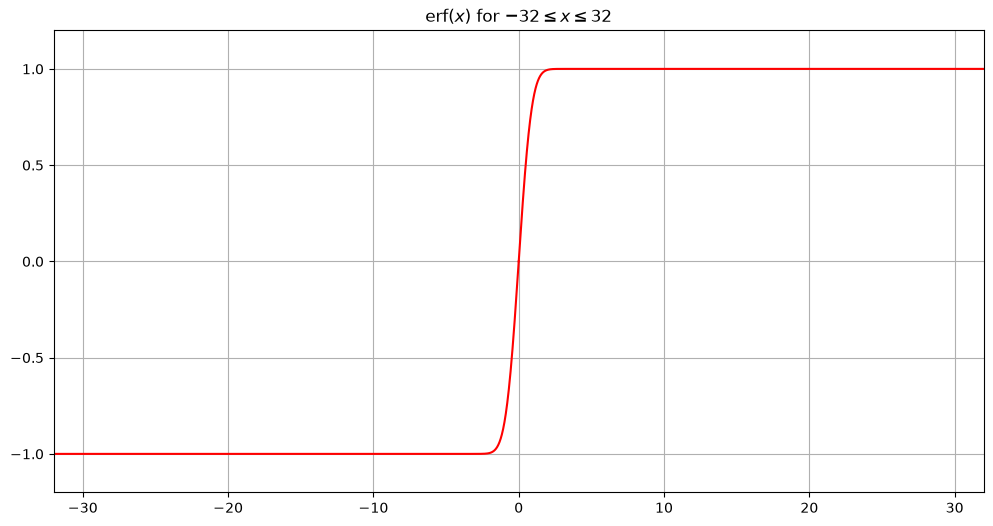

In [2]:
func = lambda x, y: 2*np.exp(-x**2)/np.sqrt(np.pi)
a = 0
b = 32
h = 0.01
data = {
    "func": func,
    "initial": 0
}

x, y = ivp.rk4(a, b, h, **data)

plt.figure(figsize=(12, 6))
plt.title(r"$\mathrm{erf}(x)$"+" for "+r"$-32\leq x\leq32$")
plt.plot(x, y, color="red")
plt.plot(-x, -y, color="red")
plt.xlim(-b, b)
plt.ylim(-1.2, 1.2)
plt.grid()
plt.show()